In [4]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import os

In [5]:
#charger population
df_pop = pd.read_excel("data/raw/Population_communes.xlsx", skiprows = 7, sheet_name = "Communes")

#charger degré de densité de population en 2022
df_densite = pd.read_excel("data/raw/Degre_densite.xlsx", skiprows = 4)

#Aperçu des données
print("Degré de densité:")
display(df_densite.head())

print("Population:")
display(df_pop.head())


Degré de densité:


,CODGEO,LIBGEO,DENS,LIBDENS,PMUN22,P1,P2,P3,DENS_AAV,LIBDENS_AAV,DENS7,LIBDENS7
0,01001,L'Abergement-Clémenciat,3,Rural,859,0.0,0.000000,100.000000,4,Rural non périurbain,6,Rural à habitat dispersé
1,01002,L'Abergement-de-Varey,3,Rural,273,0.0,0.000000,100.000000,4,Rural non périurbain,6,Rural à habitat dispersé
2,01004,Ambérieu-en-Bugey,2,Urbain intermédiaire,15554,0.0,96.933762,3.066238,2,Urbain intermédiaire,2,Centres urbains intermédiaires
3,01005,Ambérieux-en-Dombes,3,Rural,1917,0.0,0.000000,100.000000,3,Rural périurbain,5,Bourgs ruraux
4,01006,Ambléon,3,Rural,114,0.0,0.000000,100.000000,4,Rural non périurbain,6,Rural à habitat dispersé


Population:


,Code région,Nom de la région,Code département,Code arrondissement,Code canton,Code commune,Nom de la commune,Population municipale,Population comptée à part,Population totale
0,84,Auvergne-Rhône-Alpes,01,2.0,08,1,L' Abergement-Clémenciat,860,16,876
1,84,Auvergne-Rhône-Alpes,01,1.0,01,2,L' Abergement-de-Varey,270,6,276
2,84,Auvergne-Rhône-Alpes,01,1.0,01,4,Ambérieu-en-Bugey,15934,405,16339
3,84,Auvergne-Rhône-Alpes,01,2.0,22,5,Ambérieux-en-Dombes,1906,24,1930
4,84,Auvergne-Rhône-Alpes,01,1.0,04,6,Ambléon,115,0,115


In [6]:
print(df_densite.columns)
print(df_pop.columns)

Index(['CODGEO', 'LIBGEO', 'DENS', 'LIBDENS', 'PMUN22', 'P1', 'P2', 'P3',
       'DENS_AAV', 'LIBDENS_AAV', 'DENS7', 'LIBDENS7'],
      dtype='object')
Index(['Code région', 'Nom de la région', 'Code département',
       'Code arrondissement', 'Code canton', 'Code commune',
       'Nom de la commune', 'Population municipale',
       'Population comptée à part', 'Population totale'],
      dtype='object')


In [7]:
#sélection des colonnes les plus intéressantes dans le degré de densité

df_densite_clean = df_densite[["CODGEO", "LIBDENS", "LIBDENS_AAV", "LIBDENS7"]].copy()

df_densite_clean.columns = ["code_commune", "degre_densite", "degre_densite_AAV", "degre_densite_7"]

df_densite_clean.columns
print(df_densite_clean.head())

  code_commune         degre_densite     degre_densite_AAV  \
0        01001                 Rural  Rural non périurbain   
1        01002                 Rural  Rural non périurbain   
2        01004  Urbain intermédiaire  Urbain intermédiaire   
3        01005                 Rural      Rural périurbain   
4        01006                 Rural  Rural non périurbain   

                  degre_densite_7  
0        Rural à habitat dispersé  
1        Rural à habitat dispersé  
2  Centres urbains intermédiaires  
3                   Bourgs ruraux  
4        Rural à habitat dispersé  


In [47]:
#enregistrement de la nouvelle base de densité dans le dossier processed
# Définition du chemin de destination
target_path = "data/processed/df_densite_clean.xlsx"

# Vérification/Création du dossier de destination
os.makedirs(os.path.dirname(target_path), exist_ok=True)

# Enregistrement en format Excel
df_densite_clean.to_excel(target_path, index=False, sheet_name='Densite_Nettoyee')

print(f"Fichier sauvegardé dans : {target_path}")

Fichier sauvegardé dans : data/processed/df_densite_clean.xlsx


In [13]:
#lecture du fichier csv des élections
df_ele = pd.read_csv("data/raw/resultats_definitifs_par_communes.csv", sep=";", low_memory=False)
print(df_ele.head())

  Code département Libellé département Code commune          Libellé commune  \
0                1                 Ain         1001  L'Abergement-Clémenciat   
1                1                 Ain         1002    L'Abergement-de-Varey   
2                1                 Ain         1004        Ambérieu-en-Bugey   
3                1                 Ain         1005      Ambérieux-en-Dombes   
4                1                 Ain         1006                  Ambléon   

   Inscrits  Votants % Votants  Abstentions % Abstentions  Exprimés  ...  \
0       662      492    74,32%          170        25,68%       476  ...   
1       228      178    78,07%           50        21,93%       171  ...   
2      8744     6037    69,04%         2707        30,96%      5890  ...   
3      1337      960    71,80%          377        28,20%       941  ...   
4        98       68    69,39%           30        30,61%        65  ...   

  Elu 203 Numéro de panneau 204  Nuance candidat 204 Nom candi

In [14]:

#visualisation des colonnes vides

df_ele.isna().sum()


Code département           0
Libellé département        0
Code commune               0
Libellé commune            0
Inscrits                   0
                       ...  
Sexe candidat 204      35231
Voix 204               35231
% Voix/inscrits 204    35231
% Voix/exprimés 204    35231
Elu 204                35232
Length: 1854, dtype: int64

In [22]:
#création de la colonne code_commune avec 5 chiffres pour le futur merge

df_clean = df_ele.copy()
df_clean['code_commune'] = df_ele['Code commune'].astype(str).str.zfill(5)
df_clean = df_clean.drop('Code commune', axis=1)

#je replace la nouvelle colonne code_commune en 3ème position comme l'ancienne

cols = list(df_clean.columns)
cols.remove('code_commune')
cols.insert(2, 'code_commune')
df_ele_clean = df_clean[cols]
print(df_clean.head())

  Code département Libellé département          Libellé commune  Inscrits  \
0                1                 Ain  L'Abergement-Clémenciat       662   
1                1                 Ain    L'Abergement-de-Varey       228   
2                1                 Ain        Ambérieu-en-Bugey      8744   
3                1                 Ain      Ambérieux-en-Dombes      1337   
4                1                 Ain                  Ambléon        98   

   Votants % Votants  Abstentions % Abstentions  Exprimés % Exprimés/inscrits  \
0      492    74,32%          170        25,68%       476              71,90%   
1      178    78,07%           50        21,93%       171              75,00%   
2     6037    69,04%         2707        30,96%      5890              67,36%   
3      960    71,80%          377        28,20%       941              70,38%   
4       68    69,39%           30        30,61%        65              66,33%   

   ... Numéro de panneau 204  Nuance candidat 204 

In [48]:
#nettoyage du fichier en le transformant d'un fichier wide à un fichier long

print("Transformation du fichier (Pivotage des colonnes candidats)...")
    
# On prépare une liste pour stocker les morceaux
pieces = []
    
# On identifie combien de colonnes 'Nuance candidat X' existent
# On regarde jusqu'à 200 candidats potentiels (largeur max)
cols_fixes = ['Code département', 'Libellé département', 'code_commune', 'Libellé commune', 'Inscrits', 'Exprimés']
    
for i in range(1, 200):
    col_nuance = f'Nuance candidat {i}'
    col_voix = f'Voix {i}'
        
    # Si la colonne n'existe plus, on arrête
    if col_nuance not in df_clean.columns:
        break
            
    # On prend juste ce morceau (Commune + Candidat i)
    temp = df_clean[cols_fixes + [col_nuance, col_voix]].copy()
    temp.columns = cols_fixes + ['Nuance', 'Voix'] # On renomme pour standardiser
        
    # On nettoie les lignes vides (pas de candidat n°X dans cette commune)
    temp = temp.dropna(subset=['Nuance'])
    pieces.append(temp)
    
# On recolle tous les morceaux les uns sous les autres
df_long = pd.concat(pieces, ignore_index=True)
df_long.head()

Transformation du fichier (Pivotage des colonnes candidats)...


,Code département,Libellé département,code_commune,Libellé commune,Inscrits,Exprimés,Nuance,Voix
0,1,Ain,01001,L'Abergement-Clémenciat,662,476,UG,83.0
1,1,Ain,01002,L'Abergement-de-Varey,228,171,ECO,2.0
2,1,Ain,01004,Ambérieu-en-Bugey,8744,5890,ECO,51.0
3,1,Ain,01005,Ambérieux-en-Dombes,1337,941,UG,173.0
4,1,Ain,01006,Ambléon,98,65,ENS,22.0


In [49]:
#simplification des nuances en 4 catégories politiques: gauche, centre, droite et extrême droite

df_long['Voix'] = pd.to_numeric(df_long['Voix'], errors='coerce').fillna(0)
df_long['Exprimés'] = pd.to_numeric(df_long['Exprimés'], errors='coerce').fillna(0)

# D. APPLICATION DES 4 BLOCS
print("Création des blocs politiques...")
    
def attribuer_bloc_precis(nuance):
    # Gauche NFP
    if nuance in ['UG', 'VEC', 'FI', 'SOC', 'COM', 'ECO', 'DVG', 'RDG', 'DXG']: return 'GAUCHE_NFP'
    # Centre
    elif nuance in ['ENS', 'DVC', 'UDI', 'HOR', 'MDM', 'REN']: return 'CENTRE'
    # Droite Républicaine (Le 4ème bloc)
    elif nuance in ['LR', 'DVD']: return 'DROITE'
    # Extrême Droite
    elif nuance in ['RN', 'UXD', 'REC', 'DSV']: return 'EXTREME_DROITE'
    else: return 'AUTRE'

df_long['BLOC'] = df_long['Nuance'].apply(attribuer_bloc_precis)

Création des blocs politiques...


In [50]:
#vérifiation que les résultats sont cohérents

resultats_blocs = df_long.groupby('BLOC')['Voix'].sum().reset_index()
total_voix = resultats_blocs['Voix'].sum()
resultats_blocs['Pourcentage'] = (resultats_blocs['Voix'] / total_voix) * 100
resultats_blocs = resultats_blocs.sort_values(by='Pourcentage', ascending=False)

print(resultats_blocs)

             BLOC        Voix  Pourcentage
3  EXTREME_DROITE  10958775.0    34.206120
4      GAUCHE_NFP   9703531.0    30.288070
1          CENTRE   7194967.0    22.457976
2          DROITE   3276680.0    10.227649
0           AUTRE    903516.0     2.820185


In [72]:
print("Calcul des scores finaux...")
df_final = df_long.pivot_table(
    index=['Code département', 'Libellé département', 'code_commune', 'Libellé commune'],
    columns='BLOC',
    values='Voix',
    aggfunc='sum').fillna(0).reset_index()
    
# Calcul des pourcentages
colonnes_blocs = ['GAUCHE_NFP', 'CENTRE', 'DROITE', 'EXTREME_DROITE', 'AUTRE']
df_final['Total_Calcule'] = df_final[colonnes_blocs].sum(axis=1)
    
# On évite la division par zéro
df_final = df_final[df_final['Total_Calcule'] > 0].copy()
    
for bloc in ['GAUCHE_NFP', 'CENTRE', 'DROITE', 'EXTREME_DROITE', 'AUTRE']:
    df_final[f'Pct_{bloc}'] = (df_final[bloc] / df_final['Total_Calcule']) * 100

df_final

# --- EXECUTION ---

print("\n--- RÉSULTAT FINAL ---")
display(df_final.head())
print(f"Nombre de communes traitées : {len(df_final)}")

# Nombre de lignes, Nombre de colonnes)
print(df_final.shape)

Calcul des scores finaux...

--- RÉSULTAT FINAL ---


BLOC,Code département,Libellé département,code_commune,Libellé commune,AUTRE,CENTRE,DROITE,EXTREME_DROITE,GAUCHE_NFP,Total_Calcule,Pct_GAUCHE_NFP,Pct_CENTRE,Pct_DROITE,Pct_EXTREME_DROITE,Pct_AUTRE
0,1,Ain,01001,L'Abergement-Clémenciat,2.0,86.0,47.0,258.0,83.0,476.0,17.436975,18.067227,9.873950,54.201681,0.420168
1,1,Ain,01002,L'Abergement-de-Varey,1.0,19.0,45.0,42.0,64.0,171.0,37.426901,11.111111,26.315789,24.561404,0.584795
2,1,Ain,01004,Ambérieu-en-Bugey,94.0,789.0,989.0,2208.0,1810.0,5890.0,30.730051,13.395586,16.791171,37.487267,1.595925
3,1,Ain,01005,Ambérieux-en-Dombes,15.0,198.0,61.0,494.0,173.0,941.0,18.384697,21.041445,6.482465,52.497343,1.594049
4,1,Ain,01006,Ambléon,2.0,22.0,3.0,24.0,14.0,65.0,21.538462,33.846154,4.615385,36.923077,3.076923


Nombre de communes traitées : 35229
(35229, 15)


In [77]:
# Fusion des deux DataFrames sur la colonne 'code_commune'
df_final2 = pd.merge(df_final, df_densite_clean, on='code_commune', how='left')

#suppression des colonnes moins intéressantes: choix de garder degre-densite-aav car la présence dans l'aire d'attraction d'une ville semble pertinente pour expliquer les votes aussi
df_final2= df_final2.drop(columns=['DROITE', 'CENTRE', 'AUTRE', 'EXTREME_DROITE', 'GAUCHE_NFP', 
                                   'Total_Calcule', 'degre_densite', 'degre_densite_7', 'Libellé département', 
                                  'Code département'])
# Vérification du résultat
print(f"Taille après fusion : {df_final2.shape}")
df_final2.head()

Taille après fusion : (35229, 8)


,code_commune,Libellé commune,Pct_GAUCHE_NFP,Pct_CENTRE,Pct_DROITE,Pct_EXTREME_DROITE,Pct_AUTRE,degre_densite_AAV
0,01001,L'Abergement-Clémenciat,17.436975,18.067227,9.873950,54.201681,0.420168,Rural non périurbain
1,01002,L'Abergement-de-Varey,37.426901,11.111111,26.315789,24.561404,0.584795,Rural non périurbain
2,01004,Ambérieu-en-Bugey,30.730051,13.395586,16.791171,37.487267,1.595925,Urbain intermédiaire
3,01005,Ambérieux-en-Dombes,18.384697,21.041445,6.482465,52.497343,1.594049,Rural périurbain
4,01006,Ambléon,21.538462,33.846154,4.615385,36.923077,3.076923,Rural non périurbain


In [78]:
# Donne un résumé statistique complet pour chaque catégorie
df_final2.groupby('degre_densite_AAV')[colonnes_scores].describe()

Pct_GAUCHE_NFP                                        \
                              count       mean        std  min        25%   
degre_densite_AAV                                                           
Rural non périurbain        16136.0  22.895980  13.386124  0.0  13.511463   
Rural périurbain            14446.0  21.981375  10.376327  0.0  15.007476   
Urbain dense                  699.0  37.052703  13.307589  0.0  28.173524   
Urbain intermédiaire         3579.0  24.925207   9.328759  0.0  18.741978   

                                                      Pct_CENTRE             \
                            50%        75%        max      count       mean   
degre_densite_AAV                                                             
Rural non périurbain  20.000000  30.000000  92.307692    16136.0  16.788600   
Rural périurbain      20.493251  27.391023  90.909091    14446.0  19.442636   
Urbain dense          35.605663  44.256290  78.365836      699.0  23.504883   
Urbain intermédiaire  23.809524  29.672850  81.161137     3579.0  22.361784   

                      ... Pct_DROITE            Pct_EXTREME_DROITE             \
                      ...        75%        max              count       mean   
degre_densite_AAV     ...                                                       
Rural non périurbain  ...  25.503356  86.000000            16136.0  42.313965   
Rural périurbain      ...  18.702690  98.619448            14446.0  43.714512   
Urbain dense          ...  10.287960  78.107724              699.0  28.674937   
Urbain intermédiaire  ...  13.197625  98.577470             3579.0  39.710691   

                                                                       \
                            std  min        25%        50%        75%   
degre_densite_AAV                                                       
Rural non périurbain  12.968951  0.0  34.328358  42.656429  51.021570   
Rural périurbain      11.861522  0.0  36.889298  44.241028  51.403383   
Urbain dense          10.624250  0.0  21.455987  27.672740  34.609969   
Urbain intermédiaire  11.123944  0.0  32.411704  39.514731  47.273628   

                                  
                             max  
degre_densite_AAV                 
Rural non périurbain  100.000000  
Rural périurbain       91.304348  
Urbain dense           66.555613  
Urbain intermédiaire   70.000000  

[4 rows x 32 columns]

In [82]:
#visualisation des résultats selon la classification des villes plus propre que fonction describe

# 1. Liste des colonnes de scores à analyser
colonnes_scores = [
    'Pct_GAUCHE_NFP', 
    'Pct_CENTRE', 
    'Pct_DROITE', 
    'Pct_EXTREME_DROITE',
    'Pct_AUTRE'
]

# 2. Groupement par densité et calcul des statistiques descriptives
# On utilise .agg() pour obtenir plusieurs indicateurs d'un coup
stats_completes = df_final2.groupby('degre_densite_AAV')[colonnes_scores].agg([
    'mean',    # Moyenne
    'median',  # Médiane
    'std',     # Écart-type (dispersion)
    'min',     # Score minimum
    'max'      # Score maximum
]).round(2)

# 3. Affichage du tableau final
print("Synthèse des votes par densité (Source: df_final2) :")
display(stats_completes)

Synthèse des votes par densité (Source: df_final2) :


Pct_GAUCHE_NFP                           Pct_CENTRE  \
                               mean median    std  min    max       mean   
degre_densite_AAV                                                          
Rural non périurbain          22.90  20.00  13.39  0.0  92.31      16.79   
Rural périurbain              21.98  20.49  10.38  0.0  90.91      19.44   
Urbain dense                  37.05  35.61  13.31  0.0  78.37      23.50   
Urbain intermédiaire          24.93  23.81   9.33  0.0  81.16      22.36   

                                                ... Pct_EXTREME_DROITE         \
                     median    std  min    max  ...               mean median   
degre_densite_AAV                               ...                             
Rural non périurbain  16.31  13.76  0.0  89.01  ...              42.31  42.66   
Rural périurbain      20.40  13.01  0.0  73.17  ...              43.71  44.24   
Urbain dense          24.44  12.64  0.0  57.88  ...              28.67  27.67   
Urbain intermédiaire  23.38  12.94  0.0  57.45  ...              39.71  39.51   

                                         Pct_AUTRE                           
                        std  min     max      mean median   std  min    max  
degre_densite_AAV                                                            
Rural non périurbain  12.97  0.0  100.00      3.60   1.46  9.02  0.0  89.06  
Rural périurbain      11.86  0.0   91.30      3.05   1.42  7.78  0.0  91.30  
Urbain dense          10.62  0.0   66.56      2.45   1.42  5.69  0.0  78.57  
Urbain intermédiaire  11.12  0.0   70.00      2.76   1.54  6.19  0.0  78.94  

[4 rows x 25 columns]

In [79]:
# 1. On définit les blocs que l'on veut voir en colonnes
colonnes_scores = [
    'Pct_GAUCHE_NFP', 
    'Pct_CENTRE', 
    'Pct_DROITE', 
    'Pct_EXTREME_DROITE',
    'Pct_AUTRE'
]

# 2. On calcule la moyenne par catégorie de densité
# Cela place automatiquement 'degre_densite_AAV' en lignes et les blocs en colonnes
tableau_recap = df_final2.groupby('degre_densite_AAV')[colonnes_scores].mean().round(2)

# 3. On ajoute un symbole '%' pour la lisibilité (optionnel, transforme les nombres en texte)
tableau_visuel = tableau_recap.astype(str) + ' %'

# Affichage
print("Tableau de synthèse des votes moyens par densité :")
display(tableau_visuel)

Tableau de synthèse des votes moyens par densité :


,Pct_GAUCHE_NFP,Pct_CENTRE,Pct_DROITE,Pct_EXTREME_DROITE,Pct_AUTRE
degre_densite_AAV,,,,,
Rural non périurbain,22.9 %,16.79 %,14.4 %,42.31 %,3.6 %
Rural périurbain,21.98 %,19.44 %,11.81 %,43.71 %,3.05 %
Urbain dense,37.05 %,23.5 %,8.31 %,28.67 %,2.45 %
Urbain intermédiaire,24.93 %,22.36 %,10.25 %,39.71 %,2.76 %


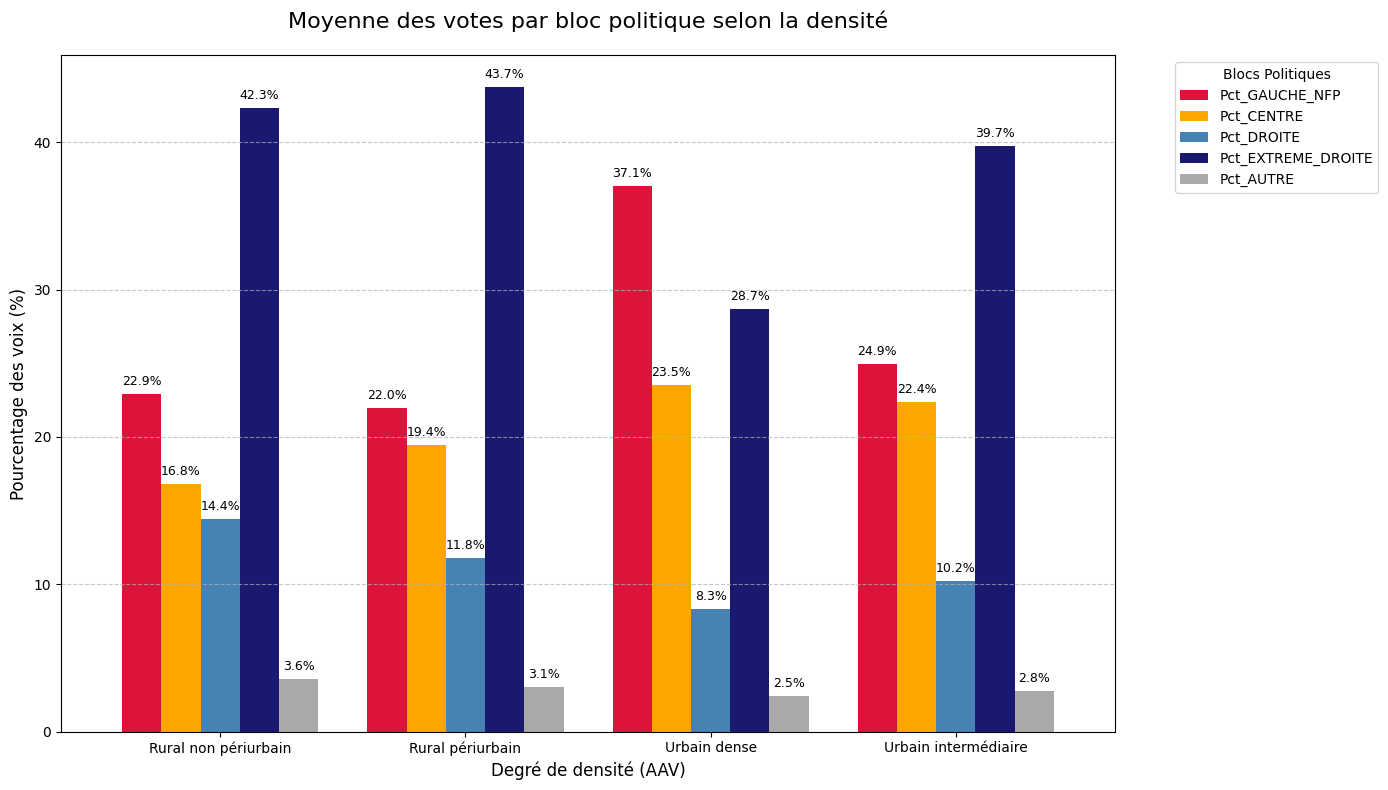

In [81]:
# On prépare les données
colonnes_scores = ['Pct_GAUCHE_NFP', 'Pct_CENTRE', 'Pct_DROITE', 'Pct_EXTREME_DROITE', 'Pct_AUTRE']
df_plot = df_final2.groupby('degre_densite_AAV')[colonnes_scores].mean()

# Création du graphique
ax = df_plot.plot(kind='bar', figsize=(14, 8), width=0.8, color=['crimson', 'orange', 'steelblue', 'midnightblue',
                                                                'darkgray'])

# Personnalisation du style
plt.title('Moyenne des votes par bloc politique selon la densité', fontsize=16, pad=20)
plt.xlabel('Degré de densité (AAV)', fontsize=12)
plt.ylabel('Pourcentage des voix (%)', fontsize=12)
plt.legend(title='Blocs Politiques', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)  # Garde les chiffres de l'abscisse à l'endroit
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajout des étiquettes de score au-dessus des bâtons
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()
plt.show()